Title: SEM_application_with_CESM2LE_15_24.ipynb

Purpose: Apply the simple energy model to the preprocessed CMIP6 data with warming level of 2K in comparison to preindustrial levels

Author: Onno Nennecke on 19.03.2025 Modified: 20.02.2026

Input data: 

- Preprocessed CMIP6 Data
    - This file lies here: '/climca/people/onennecke/not_debiased_data/'
- Preprocessed ERA5 Data 
    - This file lies here: '/climca/people/onennecke/not_debiased_data/'
- Installed capacity grids: wind_offshore_ic.nc, wind_onshore_ic.nc, solar_ic_netto.nc
    - These files lie here: /climca/people/onennecke/Wind_Solar_MaStR/processed_data/
- Wind hub height grids: wind_offshore_height_weighted.nc, wind_onshore_height_weighted.nc
    - These files lie here: /climca/people/onennecke/Wind_Solar_MaStR/processed_data/ 
- Regridded population data: population_regrid_weights.nc
    - This file lies here: /climca/people/onennecke/population_data/
- Fit values from vdW Paper: demand_fit_values_week.nc
    - This file lies here: /climca/people/onennecke/population_data/

Output data:

- Timeseries of production, demand and RL
    - This file lies here: f'/climca/people/onennecke/model_output/not_bias_corrected/full_year/{ESM}_{run}_timeseries.nc'
    - Bias corrected (Not used): (This file lies here: f'/climca/people/onennecke/model_output/bias_corrected_masked_ibicus/full_year/{ESM}_{run}_timeseries.nc')

### Load libraries and functions

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
import glob
import time

# Importing functions
import Functions.wind_model_func as wind_model_func
import Functions.solar_model_func as solar_model_func
import Functions.demand as demand_func
import Functions.grid_func as grid_func
import Functions.config as config

/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


Define variables (all in the config file)


```python
Wind:
- alpha_on = 1/7    # Roughness parameter onshore  
- alpha_off = 0.11  # Roughness parameter offshore  
- ref_height = 100   # Height of wind data  
- v_cutin = 3.5     # Minimum wind speed to start producing power  
- v_cutout = 25     # Maximum wind speed to produce power  
- v_rated = 13      # Wind speed at which the turbine produces maximum power  
- time_oper = 24    # operational time of hub [h/day]  
- Hub Height:
    - # hub_height_on = 80    # Approximation: Onshore 80 m --> Bad Approximation --> Used own grid data instead  
    - # hub_height_off = 120  # Approximation: Offshore 120 m --> Bad Approximation --> Used own grid data instead  

Solar:

- cT_c1 = 4.3       # constant [dC]  
- cT_c2 = 0.943     # constant [-]  
- cT_c3 = 0.028     # constant [dC m2 W-1]  
- cT_c4 = -1.528    # constant [dC s m-1]  
- gamma = -0.005    # constant [--]  
- temp_ref = 25     # reference temperature [dC]  
- gstc = 1000       # standard test conditions [W m-2]  
- shift_doy = 186   # if HadGEM : 180  
```

### Load datasets

In [2]:
# Load installed capacity data
grid_offshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic.nc')
grid_offshore = grid_offshore['wind_off_cap']
mask_offshore = xr.where(np.isfinite(grid_offshore), 1, 0)
grid_onshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic.nc')
grid_onshore = grid_onshore['wind_on_cap']
mask_onshore = xr.where(np.isfinite(grid_onshore), 1, 0)
grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic_netto.nc')
# grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic.nc')
grid_solar = grid_solar['solar_cap']
mask_solar = xr.where(np.isfinite(grid_solar), 1, 0)
population = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')
population = population['population']
mask_population = xr.where(np.isfinite(population), 1, 0)
# Overall mask
overall_mask = mask_offshore + mask_onshore + mask_solar + mask_population
overall_mask = xr.where(overall_mask > 0, 1, 0)

In [3]:
# Load wind height data
grid_onsh_hub_height = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_height_weighted.nc')
grid_offsh_hub_height = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted.nc')

hub_height_on = grid_onsh_hub_height['wind_on_hub_height']
hub_height_off = grid_offsh_hub_height['wind_off_hub_height']

In [4]:
# Load regridded population weights data
pop_regr_CIESIN_weights = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')

# Load fit values from vdW Paper
demand_fit_values = xr.open_dataset('/climca/people/onennecke/population_data/demand_fit_values_week.nc')

### Define used models and timeframes

In [5]:
# Read the dataframe from the csv file
# used_runs_old = pd.read_csv('/home/onennecke/CMIP_models/CMIP6_runs.csv')
# used_runs_old
used_runs_CMIP = pd.read_csv('/home/onennecke/CMIP_models/CMIP6_runs_future.csv')

used_runs_CESM = pd.read_csv('/home/onennecke/CMIP_models/CESM2_LE_runs.csv')

used_runs = pd.concat([used_runs_CMIP, used_runs_CESM], ignore_index=True)

# Add one row with ERA5 using pd.concat
era5_row = pd.DataFrame([{
    'ESM': 'ERA5',
    'Institution': 'ECMWF',
    'run': 'hist'
}])
used_runs = pd.concat([used_runs, era5_row], ignore_index=True)


# Change the ref column to 1 for the first instance of each model
used_runs['Ref'] = used_runs.groupby(['ESM', 'Institution']).cumcount().apply(lambda x: 1 if x == 0 else 0)

used_runs

,ESM,Institution,run,Ref
0,ACCESS-CM2,CSIRO-ARCCSS,r4i1p1f1,1
1,ACCESS-CM2,CSIRO-ARCCSS,r5i1p1f1,0
2,ACCESS-CM2,CSIRO-ARCCSS,r1i1p1f1,0
3,BCC-CSM2-MR,BCC,r1i1p1f1,1
4,CESM2,NCAR,r4i1p1f1,1
...,...,...,...,...
188,CESM2,NCAR,LE2-1301_017,0
189,CESM2,NCAR,LE2-1301_018,0
190,CESM2,NCAR,LE2-1301_019,0
191,CESM2,NCAR,LE2-1301_020,0


In [10]:
# Display the whole dataframe
pd.set_option('display.max_rows', None)
print(used_runs)

               ESM          Institution           run  Ref
0       ACCESS-CM2         CSIRO-ARCCSS      r4i1p1f1    1
1       ACCESS-CM2         CSIRO-ARCCSS      r5i1p1f1    0
2       ACCESS-CM2         CSIRO-ARCCSS      r1i1p1f1    0
3      BCC-CSM2-MR                  BCC      r1i1p1f1    1
4            CESM2                 NCAR      r4i1p1f1    1
5            CESM2                 NCAR     r10i1p1f1    0
6            CESM2                 NCAR     r11i1p1f1    0
7        EC-Earth3  EC-Earth-Consortium    r149i1p1f1    1
8        EC-Earth3  EC-Earth-Consortium      r4i1p1f1    0
9        EC-Earth3  EC-Earth-Consortium    r148i1p1f1    0
10       EC-Earth3  EC-Earth-Consortium    r105i1p1f1    0
11       EC-Earth3  EC-Earth-Consortium    r134i1p1f1    0
12       EC-Earth3  EC-Earth-Consortium    r141i1p1f1    0
13       EC-Earth3  EC-Earth-Consortium    r146i1p1f1    0
14       EC-Earth3  EC-Earth-Consortium    r112i1p1f1    0
15       EC-Earth3  EC-Earth-Consortium    r117i1p1f1   

### Run SEM

In [6]:
for i in range(len(used_runs)):
    run_time = time.time()
    ESM = used_runs['ESM'][i]
    Inst = used_runs['Institution'][i]
    run = used_runs['run'][i]
    print(f'Processing Run Nr. {i+1}, {ESM}, {Inst}, {run}, \n')
    base_path = '/climca/people/onennecke/not_debiased_data/'

    sel_run = glob.glob(os.path.join(base_path, f"{ESM}_{run}_*"))

    # now drop any psl files
    sel_run = [fn for fn in sel_run if '_psl' not in os.path.basename(fn)]
    # print(sel_run)
    
    combined_ds = xr.open_mfdataset(sel_run)
    combined_ds = combined_ds.assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')
    # Filter to only winter months (October to March)
    # combined_ds = combined_ds.sel(time=combined_ds.time.dt.month.isin([10, 11, 12, 1, 2, 3]))
    
    combined_ds['tas'] = combined_ds['tas'] - 273.15 # Convert temperature from Kelvin to Celsius
    combined_ds['tasmax'] = combined_ds['tasmax'] - 273.15 # Convert maximum temperature from Kelvin to Celsius
    
    wepot_off = wind_model_func.compute_wind_energy_potential(combined_ds['sfcWind'], grid_offsh_hub_height, 
                                                              config.a_offshore, config.height_ref, v_cutin=config.v_cutin0_off_unb, 
                                                              v_rated=config.v_rated0_off_unb, v_cutout=config.v_cutout0_off_unb)
    wepot_on = wind_model_func.compute_wind_energy_potential(combined_ds['sfcWind'], grid_onsh_hub_height, config.a_onshore, 
                                                             config.height_ref, v_cutin=config.v_cutin0_on_weighted, 
                                                             v_rated=config.v_rated0_on_weighted, v_cutout=config.v_cutout0_on_weighted)

    combined_ds['wind_off_pot'] = wepot_off['wind_off_pot']
    combined_ds['wind_on_pot'] = wepot_on['wind_on_pot']

    weprod_off = wind_model_func.compute_wind_energy_production(wepot_off, grid_offshore)
    weprod_on = wind_model_func.compute_wind_energy_production(wepot_on, grid_onshore)

    combined_ds['wind_off_prod'] = weprod_off['wind_off_prod']
    combined_ds['wind_on_prod'] = weprod_on['wind_on_prod']

    sepot = solar_model_func.compute_solar_energy_potential(combined_ds['rsds'], combined_ds['tas'], combined_ds['tasmax'], 
                                                            combined_ds['sfcWind'], constants=config.pv_constants_unb, 
                                                            gamma=config.gamma_unb, ref_temp=config.temp_ref_unb)

    # combined_ds['solar_pot'] = sepot['solar_pot'] 
    combined_ds['solar_pot'] = sepot

    seprod = solar_model_func.compute_solar_energy_production(sepot, grid_solar)

    # combined_ds['solar_prod'] = seprod['solar_prod']
    combined_ds['solar_prod'] = seprod


    # Calculate weighted sum
    weighted_temp_list = []
    for y in np.unique(combined_ds['tas']["time.year"].values):
        # print(y)
        ds_weigh_temp_0 = xr.Dataset()
        ds_weigh_temp_0['temp'] = (combined_ds['tas'].sel(time=str(y)) * pop_regr_CIESIN_weights['population']).sum(dim=['lat', 'lon'])
        weighted_temp_list.append(ds_weigh_temp_0)
        
    ds_weighted_temp = xr.concat(weighted_temp_list, dim="time") 

    # Calculate demand
    demand_ds = demand_func.compute_demand(ds_weighted_temp, demand_fit_values.sel(country = 9, period = 'week'))

    timeseries_ds = demand_ds.copy()

    # timeseries_ds['sfcWind_ntmsk'] = combined_ds['sfcWind'].mean(dim=['lat', 'lon'])
    # timeseries_ds['rsds_ntmsk'] = combined_ds['rsds'].mean(dim=['lat', 'lon'])
    # timeseries_ds['tas_ntmsk'] = combined_ds['tas'].mean(dim=['lat', 'lon'])
    # timeseries_ds['tasmax_ntmsk'] = combined_ds['tasmax'].mean(dim=['lat', 'lon'])
    timeseries_ds['sfcWind'] = combined_ds['sfcWind'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
    timeseries_ds['rsds']    = combined_ds['rsds'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
    timeseries_ds['tas']     = combined_ds['tas'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)
    timeseries_ds['tasmax']  = combined_ds['tasmax'].where(overall_mask == 1).mean(dim=['lat', 'lon'], skipna=True)

    timeseries_ds['wind_off_prod'] = combined_ds['wind_off_prod'].sum(dim=['lat', 'lon']) / 1000000
    timeseries_ds['wind_on_prod'] = combined_ds['wind_on_prod'].sum(dim=['lat', 'lon']) / 1000000
    timeseries_ds['solar_prod'] = combined_ds['solar_prod'].sum(dim=['lat', 'lon']) / 1000000

    timeseries_ds['total_prod'] = timeseries_ds['wind_off_prod'] + timeseries_ds['wind_on_prod'] + timeseries_ds['solar_prod']
    timeseries_ds['Netto'] = timeseries_ds['total_prod'] - timeseries_ds['demand']
    timeseries_ds['Residual_load'] = timeseries_ds['demand'] - timeseries_ds['total_prod']

    if ESM == 'ERA5':
        ts_output = timeseries_ds.assign_coords(run = 'hist', ESM = 'ERA5_week', ESM_run = 'ERA5_hist_week')
    else:
        ts_output = timeseries_ds.assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')
    
    ts_output.load()
    # ts_output.to_netcdf(f'/climca/people/onennecke/model_output/bias_corrected_masked_ibicus/full_year/{ESM}_{run}_timeseries.nc')
    ts_output.to_netcdf(f'/climca/people/onennecke/model_output/not_bias_corrected/full_year/{ESM}_{run}_timeseries.nc')

    print('Run time: ', int(np.floor((time.time()  - run_time) / 60)),'m', round((time.time()  - run_time) % 60,1),'s')
    # break
    

        

Processing Run Nr. 1, ACCESS-CM2, CSIRO-ARCCSS, r4i1p1f1, 

Run time:  0 m 0.6 s
Processing Run Nr. 2, ACCESS-CM2, CSIRO-ARCCSS, r5i1p1f1, 

Run time:  0 m 0.6 s
Processing Run Nr. 3, ACCESS-CM2, CSIRO-ARCCSS, r1i1p1f1, 

Run time:  0 m 1.0 s
Processing Run Nr. 4, BCC-CSM2-MR, BCC, r1i1p1f1, 

Run time:  0 m 0.7 s
Processing Run Nr. 5, CESM2, NCAR, r4i1p1f1, 

Run time:  0 m 0.7 s
Processing Run Nr. 6, CESM2, NCAR, r10i1p1f1, 

Run time:  0 m 0.9 s
Processing Run Nr. 7, CESM2, NCAR, r11i1p1f1, 

Run time:  0 m 0.7 s
Processing Run Nr. 8, EC-Earth3, EC-Earth-Consortium, r149i1p1f1, 

Run time:  0 m 0.8 s
Processing Run Nr. 9, EC-Earth3, EC-Earth-Consortium, r4i1p1f1, 

Run time:  0 m 0.8 s
Processing Run Nr. 10, EC-Earth3, EC-Earth-Consortium, r148i1p1f1, 

Run time:  0 m 0.7 s
Processing Run Nr. 11, EC-Earth3, EC-Earth-Consortium, r105i1p1f1, 

Run time:  0 m 0.8 s
Processing Run Nr. 12, EC-Earth3, EC-Earth-Consortium, r134i1p1f1, 

Run time:  0 m 0.6 s
Processing Run Nr. 13, EC-Earth3

In [10]:
ts_output

<xarray.Dataset> Size: 321kB
Dimensions:        (time: 3650)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
  * time           (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    ESM            <U5 20B 'CESM2'
    run            <U12 48B 'LE2-1001_001'
    ESM_run        <U18 72B 'CESM2_LE2-1001_001'
    country        float64 8B 9.0
    period         <U7 28B 'week'
Data variables:
    temp           (time) float64 29kB 5.278 7.007 6.941 ... 4.988 5.419 3.258
    demand         (time) float64 29kB 1.454e+03 1.432e+03 ... 1.48e+03
    sfcWind        (time) float32 15kB 6.146 5.676 5.677 ... 6.236 4.318 3.126
    rsds           (time) float32 15kB 0.0 17.25 21.02 ... 31.37 25.25 24.3
    tas            (time) float32 15kB 5.55 6.969 7.069 ... 5.026 5.304 3.586
    tasmax         (time) float32 15kB 5.55 9.115 9.309 ... 6.824 6.778 5.006
    wind_off_prod  (time) float64 29kB 189.6 176.0 135.3 ... 173.6 69.39 27.47
    wind_on_prod   (time) float64 29kB 255.9 157.2 157.7 ... 226.2 39.83 9.083
    solar_prod     (time) float64 29kB 0.0 40.28 52.63 ... 87.99 59.21 61.02
    total_prod     (time) float64 29kB 445.5 373.5 345.7 ... 487.7 168.4 97.58
    Netto          (time) float64 29kB -1.009e+03 -1.059e+03 ... -1.382e+03
    Residual_load  (time) float64 29kB 1.009e+03 1.059e+03 ... 1.382e+03

#### Some plots to check everything is alright

In [11]:
def setup_gridlines(ax, deg = 1, alpha = 0.4):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)

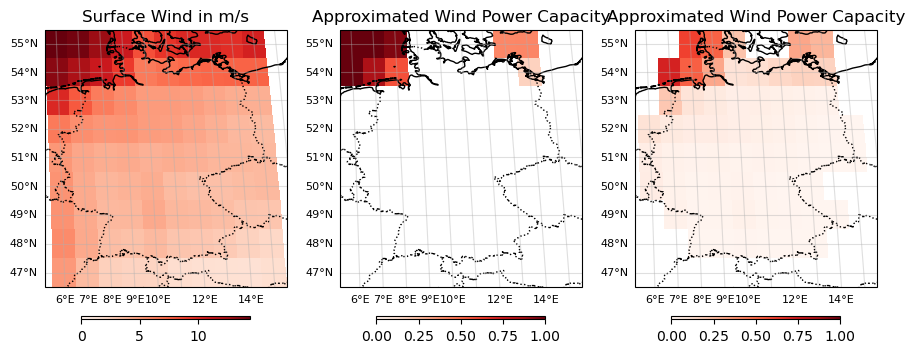

In [12]:
# Just a plot of one timestep of the wind and the approximated on- and offshore wind power capacity

lon_edges = combined_ds['lon'].values
lat_edges = combined_ds['lat'].values

vmin = 0 
vmax = 1

# Plot the data
timestep = 1 # 201

fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(9, 6), subplot_kw={'projection': ccrs.Robinson()})

# First subplot
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx1 = combined_ds['sfcWind'].isel(time=timestep)
im1 = ax1.pcolormesh(lon_edges, lat_edges, xxx1, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin)
setup_gridlines(ax1)
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax1.set_title('Surface Wind in m/s')

# Second subplot
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx2 = wepot_off['wind_off_pot'].isel(time=timestep)
im2 = ax2.pcolormesh(lon_edges, lat_edges, xxx2, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
setup_gridlines(ax2)
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax2.set_title('Approximated Wind Power Capacity')

# Third subplot
ax3.coastlines()
ax3.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx3 = wepot_on['wind_on_pot'].isel(time=timestep)
im3 = ax3.pcolormesh(lon_edges, lat_edges, xxx3, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
setup_gridlines(ax3)
cbar3 = fig.colorbar(im3, ax=ax3, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax3.set_title('Approximated Wind Power Capacity')

plt.tight_layout()
plt.show()

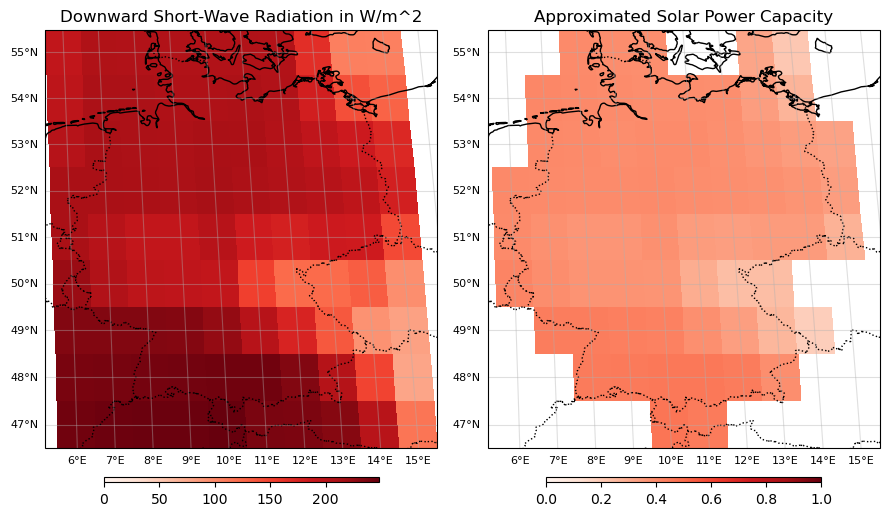

In [13]:
# Just a plot of one timestep of the solar radiation and the approximated solar power capacity
# Filter sepot so only the grids with pv data are left (mainly for plotting)
sepot_plot = sepot.where(grid_solar > 0)

# '''
lon_edges = combined_ds['lon'].values # - (combined_ds['lon'].lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = combined_ds['lat'].values # - (combined_ds['lat'].lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

vmin = 0 
vmax = 1

# Plot the data
timestep = 90# 29937# 1# 10000 # 24507

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(9, 6), subplot_kw={'projection': ccrs.Robinson()})

# First subplot
ax1.coastlines()
ax1.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx1 = combined_ds['rsds'].isel(time=timestep)
im1 = ax1.pcolormesh(lon_edges, lat_edges, xxx1, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin)
setup_gridlines(ax1)
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax1.set_title('Downward Short-Wave Radiation in W/m^2')

# Second subplot
ax2.coastlines()
ax2.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
xxx2 = sepot_plot.isel(time=timestep)
im2 = ax2.pcolormesh(lon_edges, lat_edges, xxx2, transform=ccrs.PlateCarree(), cmap='Reds', vmin=vmin, vmax=vmax)
setup_gridlines(ax2)
cbar2 = fig.colorbar(im2, ax=ax2, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)
ax2.set_title('Approximated Solar Power Capacity')

plt.tight_layout()
plt.show()
# '''

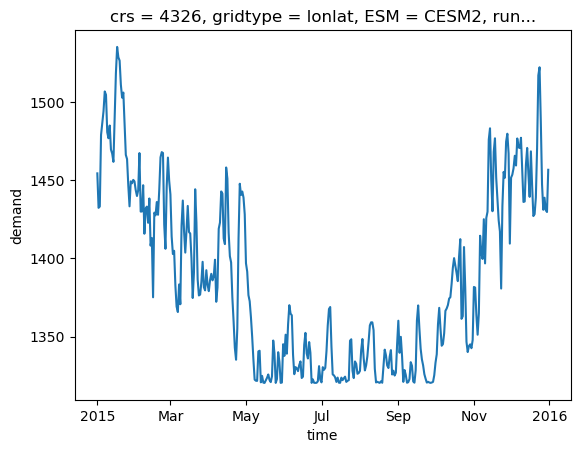

In [14]:
demand_ds['demand'][0:365].plot()

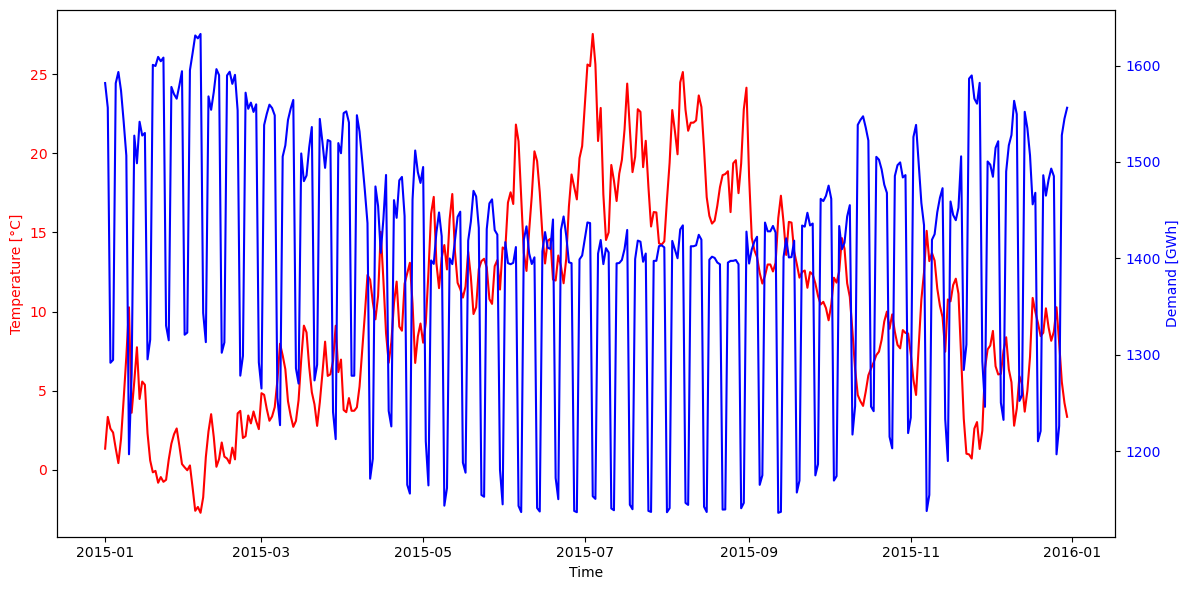

In [18]:
# Plot time series (time against temp and demand)
fig, ax1 = plt.subplots(figsize=(12, 6))

a = 0
b = 364

# Plot temperature on the first y-axis
ax1.plot(demand_ds['time'][a:b], demand_ds['temp'][a:b], label='Temperature', color='r')
ax1.set_ylabel('Temperature [°C]', color='r')
ax1.set_xlabel('Time')
ax1.tick_params(axis='y', labelcolor='r')

# Create a second y-axis to plot demand
ax2 = ax1.twinx()
ax2.plot(demand_ds['time'][a:b], demand_ds['demand'][a:b], label='Demand', color='b')
ax2.set_ylabel('Demand [GWh]', color='b')
ax2.tick_params(axis='y', labelcolor='b')
# ax2.set_ylim(1000, 2200)  # Adjust y-axis limits for demand

fig.tight_layout()
plt.show()

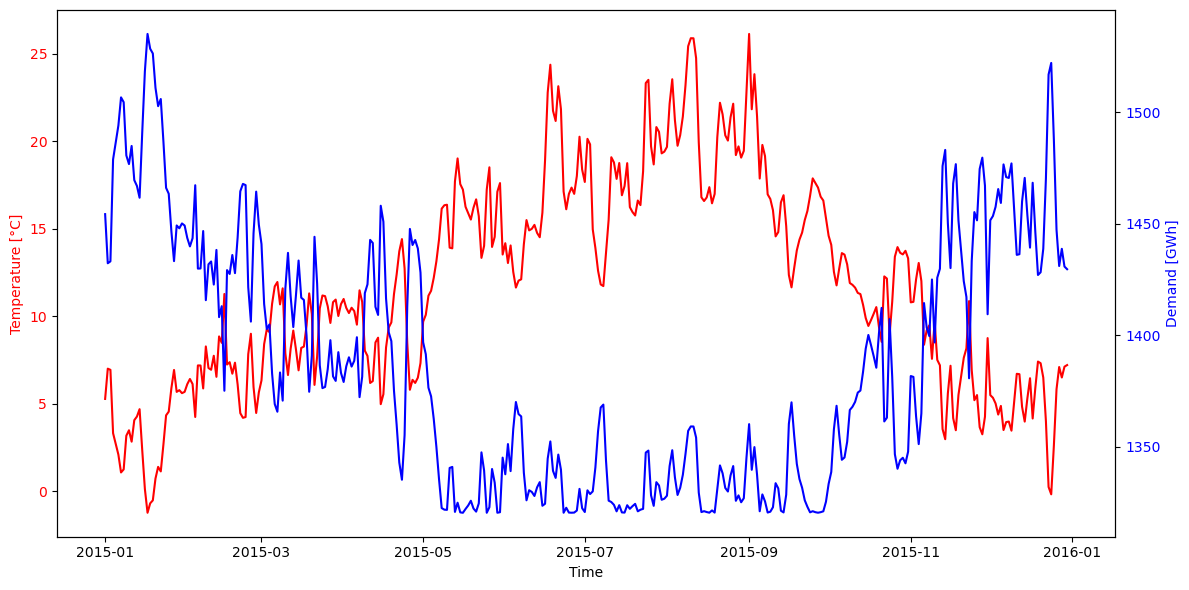

In [15]:
# Plot time series (time against temp and demand)
fig, ax1 = plt.subplots(figsize=(12, 6))

a = 0
b = 364

# Plot temperature on the first y-axis
ax1.plot(demand_ds['time'][a:b], demand_ds['temp'][a:b], label='Temperature', color='r')
ax1.set_ylabel('Temperature [°C]', color='r')
ax1.set_xlabel('Time')
ax1.tick_params(axis='y', labelcolor='r')

# Create a second y-axis to plot demand
ax2 = ax1.twinx()
ax2.plot(demand_ds['time'][a:b], demand_ds['demand'][a:b], label='Demand', color='b')
ax2.set_ylabel('Demand [GWh]', color='b')
ax2.tick_params(axis='y', labelcolor='b')
# ax2.set_ylim(1000, 2200)  # Adjust y-axis limits for demand

fig.tight_layout()
plt.show()

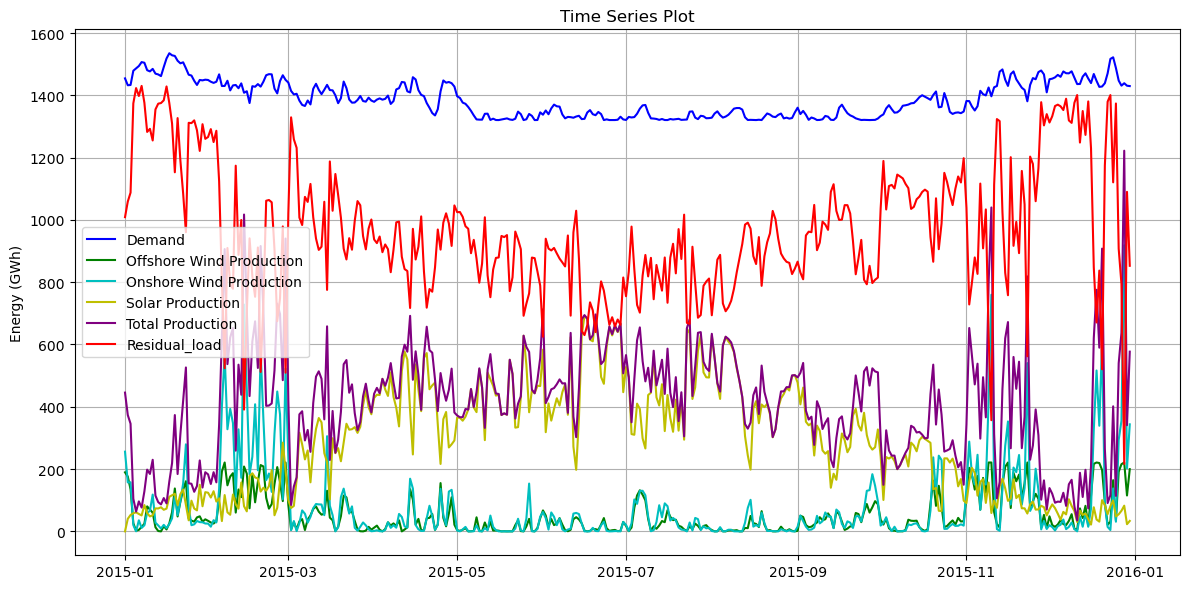

In [16]:
# Define your slice (adjust these to your desired time range)
# a = 191 + 365 * 81
# b = 7 + 365 * 82
# a = 365 * 164
# b = 365 * 165
a = 0
b = 364
# a = 365
# b = 365 * 2

# Extract time and variables for the chosen range
time = timeseries_ds['time'][a:b]
demand = timeseries_ds['demand'][a:b]
wind_off = timeseries_ds['wind_off_prod'][a:b]
wind_on = timeseries_ds['wind_on_prod'][a:b]
solar = timeseries_ds['solar_prod'][a:b]
total_prod = timeseries_ds['total_prod'][a:b]
Residual_load = timeseries_ds['Residual_load'][a:b]

# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each variable
ax.plot(time, demand, label='Demand', color='b')
ax.plot(time, wind_off, label='Offshore Wind Production', color='g')
ax.plot(time, wind_on, label='Onshore Wind Production', color='c')
ax.plot(time, solar, label='Solar Production', color='y')
ax.plot(time, total_prod, label='Total Production', color='purple')
ax.plot(time, Residual_load, label='Residual_load', color='r')

# Labeling
ax.set_xlabel('')
ax.set_ylabel('Energy (GWh)')
ax.set_title('Time Series Plot')
ax.legend()

# Formatting
fig.tight_layout()
plt.grid(True)
plt.show()

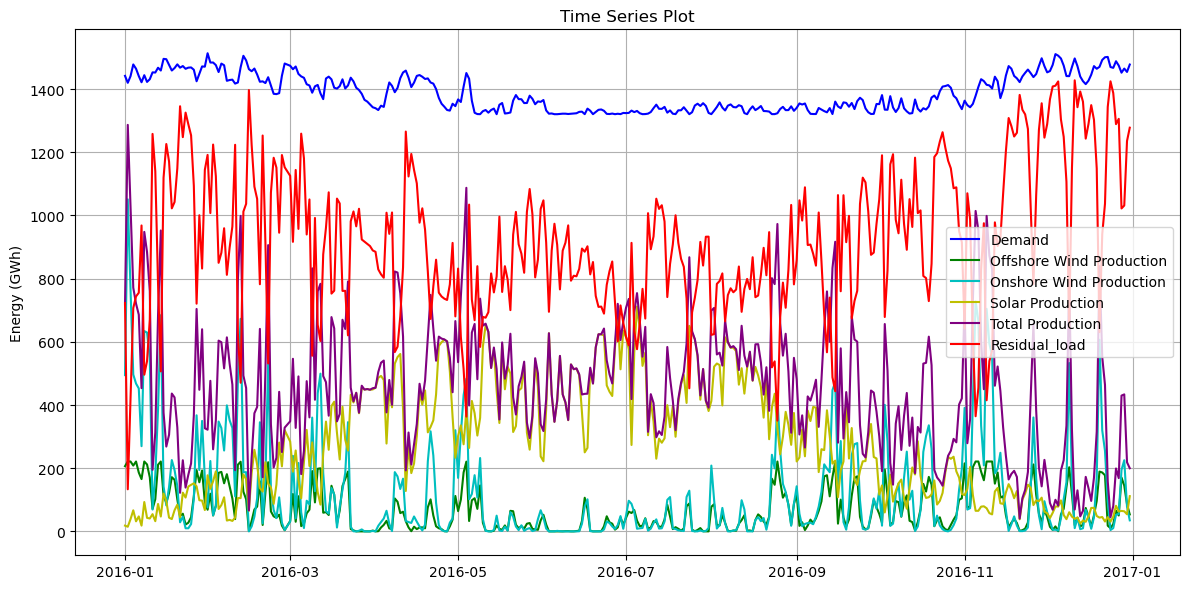

In [17]:
# Define your slice (adjust these to your desired time range)
# a = 191 + 365 * 81
# b = 7 + 365 * 82
# a = 365 * 164
# b = 365 * 165
a = 0
b = 364
a = 365
b = 365 * 2

# Extract time and variables for the chosen range
time = timeseries_ds['time'][a:b]
demand = timeseries_ds['demand'][a:b]
wind_off = timeseries_ds['wind_off_prod'][a:b]
wind_on = timeseries_ds['wind_on_prod'][a:b]
solar = timeseries_ds['solar_prod'][a:b]
total_prod = timeseries_ds['total_prod'][a:b]
Residual_load = timeseries_ds['Residual_load'][a:b]

# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each variable
ax.plot(time, demand, label='Demand', color='b')
ax.plot(time, wind_off, label='Offshore Wind Production', color='g')
ax.plot(time, wind_on, label='Onshore Wind Production', color='c')
ax.plot(time, solar, label='Solar Production', color='y')
ax.plot(time, total_prod, label='Total Production', color='purple')
ax.plot(time, Residual_load, label='Residual_load', color='r')

# Labeling
ax.set_xlabel('')
ax.set_ylabel('Energy (GWh)')
ax.set_title('Time Series Plot')
ax.legend()

# Formatting
fig.tight_layout()
plt.grid(True)
plt.show()



In [30]:
# count how many files start not with 'CESM2' in /climca/people/onennecke/not_debiased_data_future
len(glob.glob('/climca/people/onennecke/not_debiased_data_future/*')) - len(glob.glob('/climca/people/onennecke/not_debiased_data_future/CESM2_LE2*'))

460

In [29]:
len(glob.glob('/climca/people/onennecke/not_debiased_data/*')) - len(glob.glob('/climca/people/onennecke/not_debiased_data/CESM2_LE2*'))

505

In [34]:
len(glob.glob('/climca/people/onennecke/not_debiased_data_future/*'))/5

192.0

In [31]:
460/5

92.0

In [28]:
len(glob.glob('/climca/people/onennecke/not_debiased_data/EC-Earth*'))/5

54.0